In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns

In [3]:
data = pd.read_excel("C:/Users/JOHN/Desktop/boxplot_data.xlsx")

In [5]:
data

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes
5,6,Male,Sales,21,High,Yes,95,8,8,89988,No
6,7,Female,Marketing,24,Low,No,70,5,4,70934,Yes
7,8,Male,Human Resources,18,Medium,Yes,80,6,6,96578,No
8,9,Male,Engineering,20,High,Yes,90,8,7,74219,No
9,10,Female,Finance,22,Medium,Yes,85,7,6,87009,Yes


# 31.Check Distribution

In [13]:
# Identify Numeric Column

numeric_columns = [
    'Days Present',
    'Task Completion Rates',
    'Interpersonal Skills Rating',
    'Decision-Making Skills Rating',
    'Sales Revenue Generated'
]


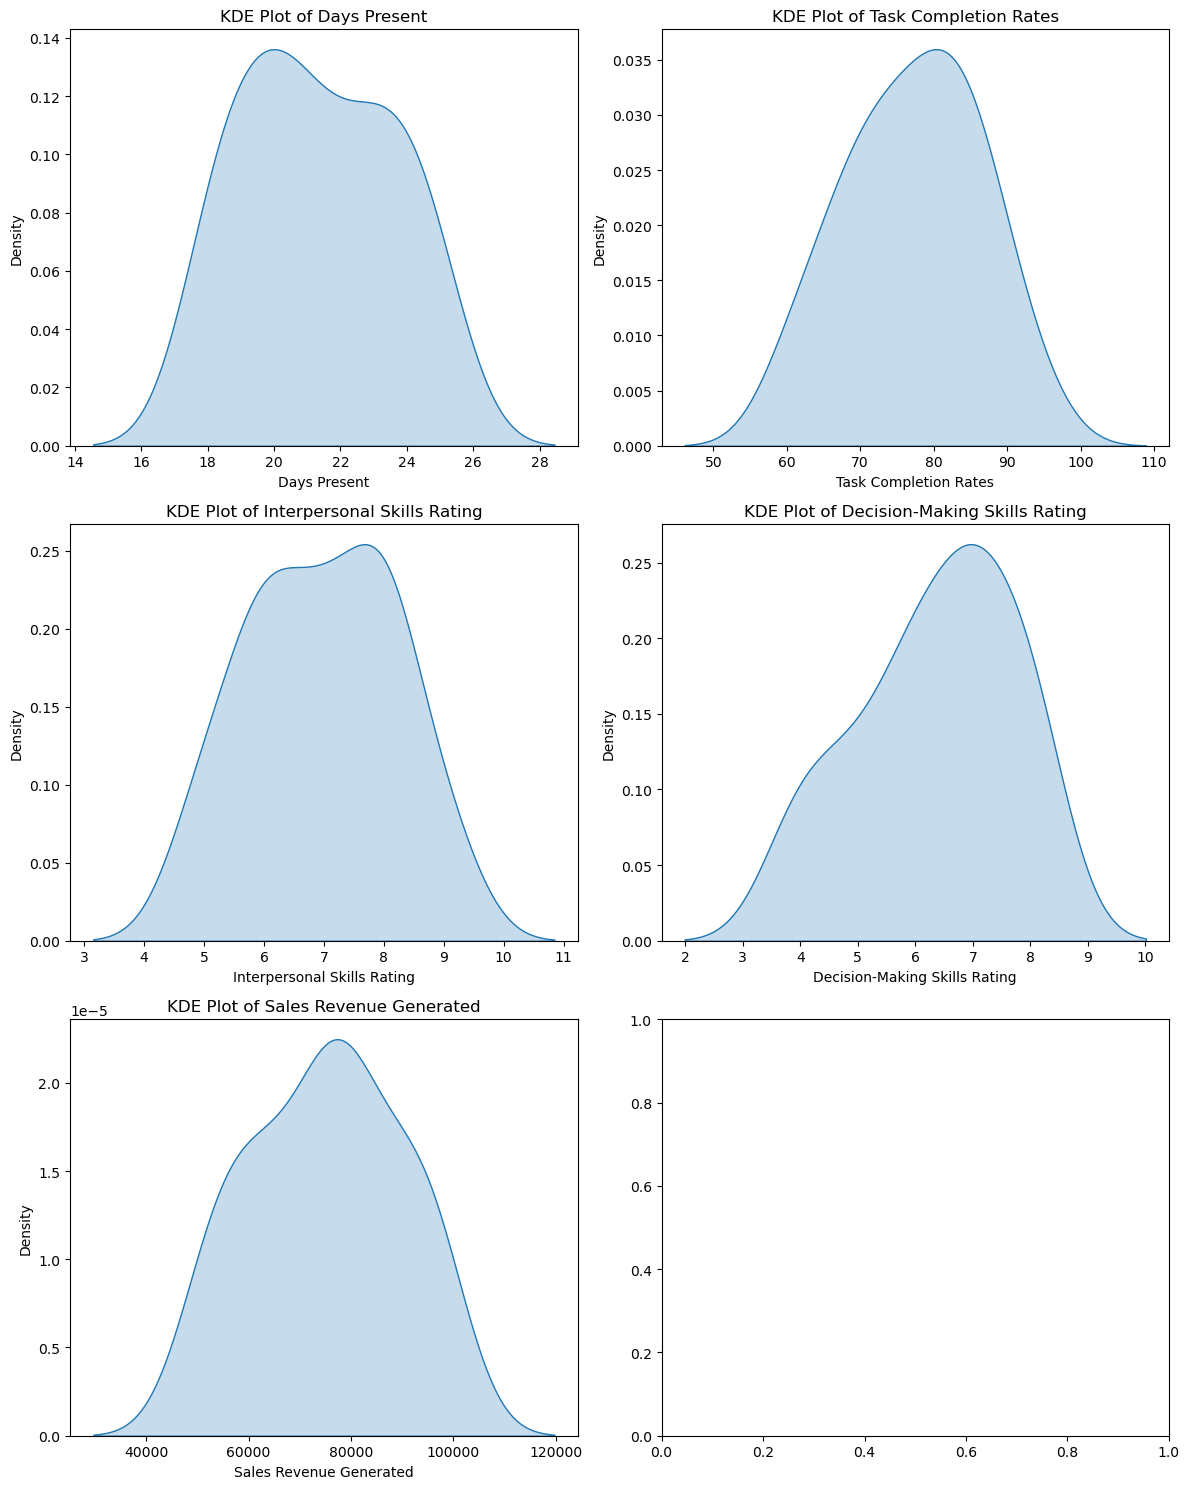

In [15]:
# KDE Plot Code

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Simple DataFrame
df = pd.read_excel("C:/Users/JOHN/Desktop/boxplot_data.xlsx")

# Define numeric columns
numeric_columns = [
    'Days Present',
    'Task Completion Rates',
    'Interpersonal Skills Rating',
    'Decision-Making Skills Rating',
    'Sales Revenue Generated'
]

# Subplot layout
num_plots = len(numeric_columns)
num_col = 2 
num_row = (num_plots + num_col - 1) // num_col 

# sub-plots within a figure
fig, axes = plt.subplots(num_row, num_col, figsize=(12, 5 * num_row))

# Flatten axes in case of fewer subplots
axes = axes.flatten()

# The elements of a list along with their index numbers
for index, column in enumerate(numeric_columns):
    sns.kdeplot(df[column].dropna(), ax=axes[index], fill=True)
    axes[index].set_title(f'KDE Plot of {column}')

# no overlap between the subplot
plt.tight_layout()
plt.show()



# 32.Normality test

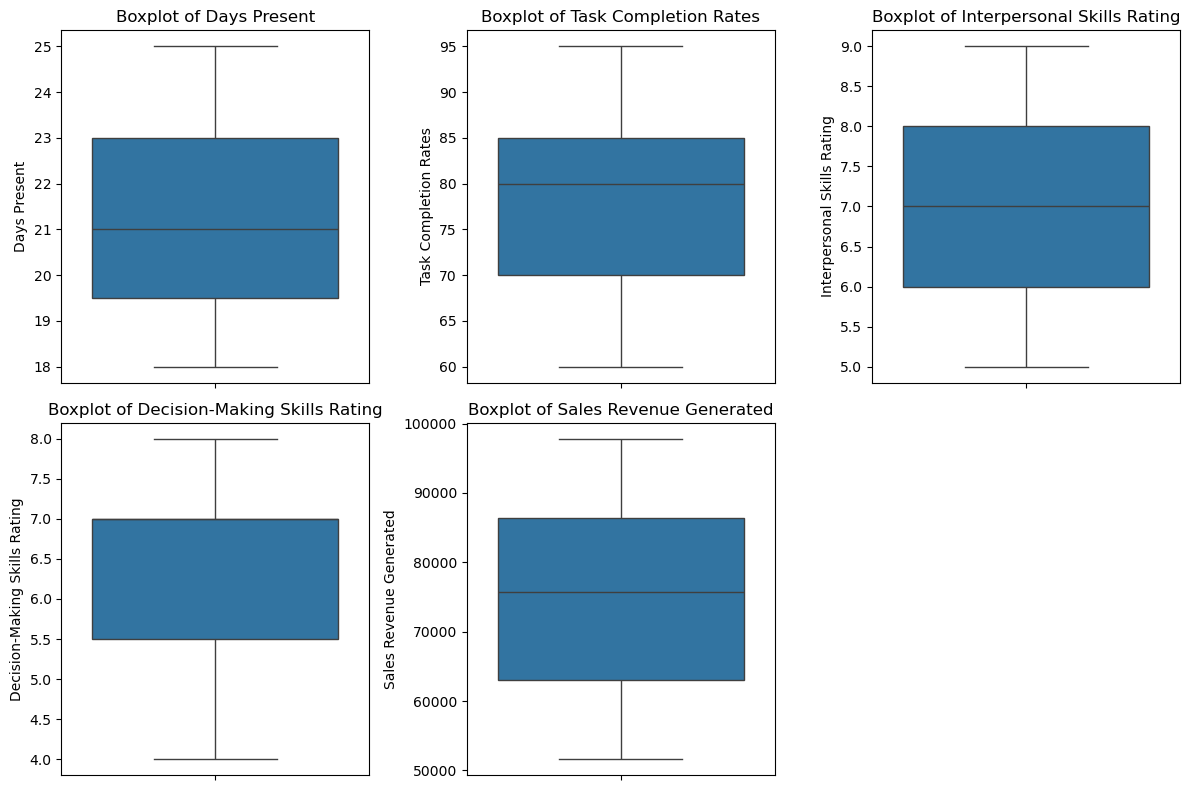

Shapiro-Wilk Test P-values:
{'Days Present': 0.044, 'Task Completion Rates': 0.321, 'Interpersonal Skills Rating': 0.015, 'Decision-Making Skills Rating': 0.004, 'Sales Revenue Generated': 0.12}


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

data['Sales Revenue Generated'] = pd.to_numeric(data['Sales Revenue Generated'], errors='coerce')
data['Task Completion Rates'] = pd.to_numeric(data['Task Completion Rates'], errors='coerce')
data['Interpersonal Skills Rating'] = pd.to_numeric(data['Interpersonal Skills Rating'], errors='coerce')
data['Decision-Making Skills Rating'] = pd.to_numeric(data['Decision-Making Skills Rating'], errors='coerce')
data['Days Present'] = pd.to_numeric(data['Days Present'], errors='coerce')

# numeric columns
numeric_columns = [
    'Days Present', 'Task Completion Rates', 'Interpersonal Skills Rating',
    'Decision-Making Skills Rating', 'Sales Revenue Generated'
]

# Boxplots for numeric columns
plt.figure(figsize=(12, 8))
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

# Shapiro-Wilk test
shapiro_results = {}

for column in numeric_columns:
    stat, p_value = shapiro(data[column])
    shapiro_results[column] = round(p_value, 3)

print("Shapiro-Wilk Test P-values:")
print(shapiro_results)


# 33.Square Root Transformation

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro


In [30]:
def sqrt_transformation(data, column_name):
    
    # square root transformation
    transformed_column = f'{column_name}_sqrt'
    data[transformed_column] = np.sqrt(data[column_name].clip(lower=0))

    # Plot the distribution
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data[transformed_column], fill=True)
    plt.title(f'Distribution after sqrt transformation: {column_name}')
    plt.xlabel(transformed_column)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

    # Shapiro-Wilk test for normality
    stat, p_value = shapiro(data[transformed_column])
    print(f'Shapiro-Wilk test for {transformed_column} - p-value: {round(p_value, 3)}')

    return data


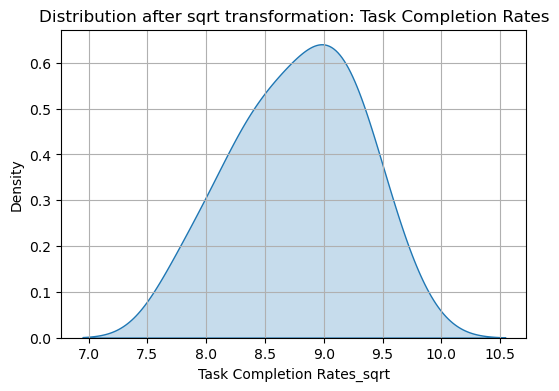

Shapiro-Wilk test for Task Completion Rates_sqrt - p-value: 0.265


In [32]:
data = sqrt_transformation(data, 'Task Completion Rates')


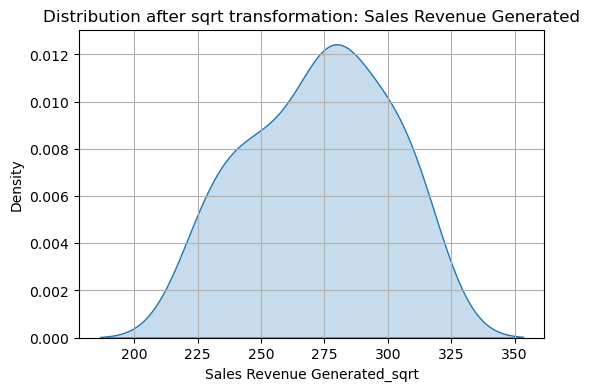

Shapiro-Wilk test for Sales Revenue Generated_sqrt - p-value: 0.099


In [34]:
data = sqrt_transformation(data, 'Sales Revenue Generated')


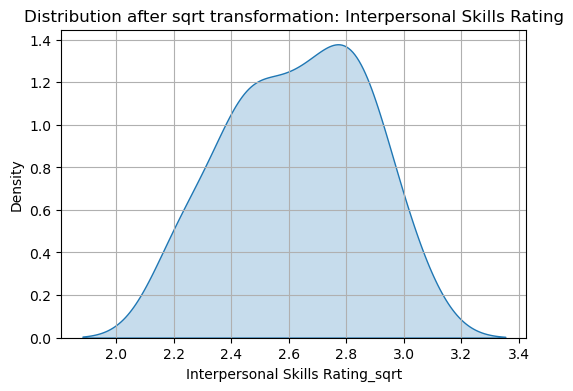

Shapiro-Wilk test for Interpersonal Skills Rating_sqrt - p-value: 0.013


In [36]:
data = sqrt_transformation(data, 'Interpersonal Skills Rating')

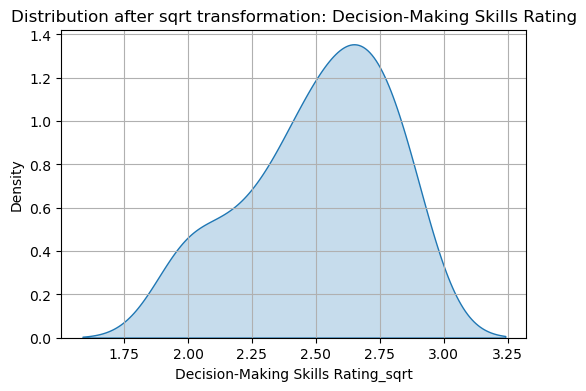

Shapiro-Wilk test for Decision-Making Skills Rating_sqrt - p-value: 0.002


In [38]:
data = sqrt_transformation(data, 'Decision-Making Skills Rating')

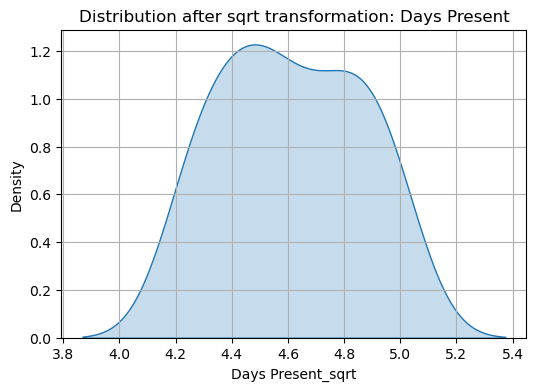

Shapiro-Wilk test for Days Present_sqrt - p-value: 0.047


In [40]:
data = sqrt_transformation(data,'Days Present')

# 34.Log Transformation

In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

def log_transformation(data, column_name):

    transformed_column = f'{column_name}_log'
    data[transformed_column] = np.log(data[column_name].clip(lower=1e-6))

    # Plot the KDE of the log-transformed column
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data[transformed_column], fill=True)
    plt.title(f'Distribution after log transformation: {column_name}')
    plt.xlabel(transformed_column)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

    # Shapiro-Wilk test
    stat, p_value = shapiro(data[transformed_column])
    print(f'Shapiro-Wilk test for {transformed_column} - p-value: {round(p_value, 3)}')

    return data


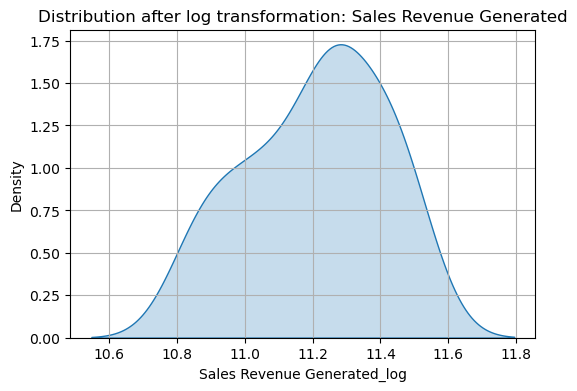

Shapiro-Wilk test for Sales Revenue Generated_log - p-value: 0.066


In [45]:
data = log_transformation(data, 'Sales Revenue Generated')


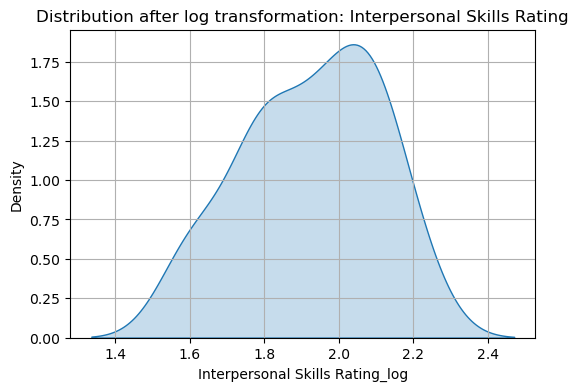

Shapiro-Wilk test for Interpersonal Skills Rating_log - p-value: 0.009


In [47]:
data = log_transformation(data, 'Interpersonal Skills Rating')


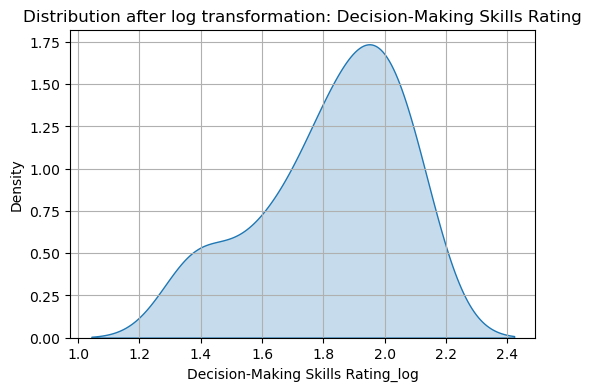

Shapiro-Wilk test for Decision-Making Skills Rating_log - p-value: 0.001


In [51]:
data = log_transformation(data, 'Decision-Making Skills Rating')

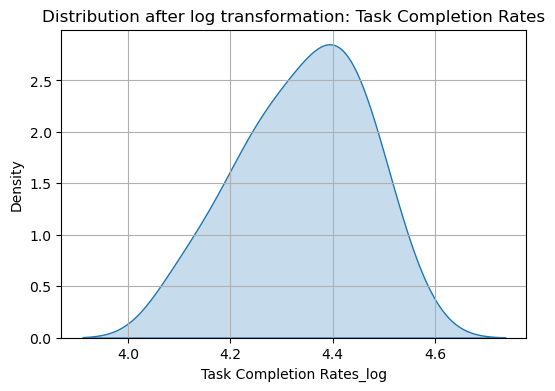

Shapiro-Wilk test for Task Completion Rates_log - p-value: 0.194


In [53]:
data = log_transformation(data, 'Task Completion Rates')

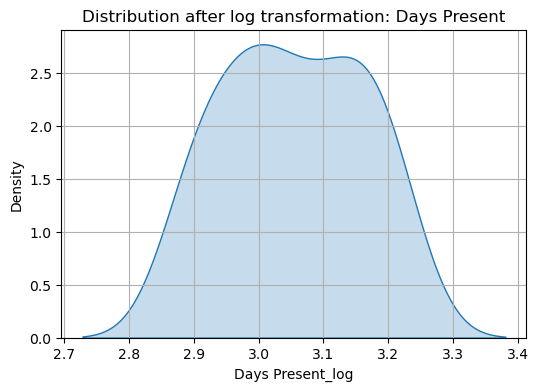

Shapiro-Wilk test for Days Present_log - p-value: 0.047


In [57]:
data = log_transformation(data,'Days Present')